In [ ]:
# "indir" is a custom input path, and "outdir" is a custom output path.
# indir=""
# outdir=""

In [ ]:
dirs <- c(
  paste0(indir,"/08_hmCG_TET1_peak/"),
  paste0(indir,"/08_mCG_TET1_peak/"),
  paste0(indir,"/08_true5mCG_TET1_peak/")
)

dirs

[1] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/ChIP_seq/cortex_to_analysis_latest/output/08_hmCG_TET1_peak/"    
[2] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/ChIP_seq/cortex_to_analysis_latest/output/08_mCG_TET1_peak/"     
[3] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/ChIP_seq/cortex_to_analysis_latest/output/08_true5mCG_TET1_peak/"

In [2]:
result <- data.frame(
  subclass = character(),
  mean_diff = numeric(),
  modification = character(),
#   statement = character(),
  stringsAsFactors = FALSE
)

In [3]:
result

subclass,mean_diff,modification
<chr>,<dbl>,<chr>


In [ ]:
basename(paste0(indir,"/08_hmCG_TET1_peak/"))

[1] "08_hmCG_TET1_peak"

In [5]:
for (dir in dirs) {
  dir_name <- basename(dir)
  modification <- sub("08_(.*)_TET1_peak", "\\1", dir_name)
#   modification_clean <- gsub("G", "", modification)
  
  files <- list.files(dir, pattern = "\\.tmp$", full.names = TRUE)
  exclude_subclasses <- c("CA1-ProS.Glut", "CA3.Glut", "DG.Glut", "OB-in.Frmd7.Gaba", "OB-STR-CTX.Inh.IMN", 
                          "STR.D2.Gaba", "OB-out.Frmd7.Gaba", "L4.RSP-ACA.Glut", "L5.NP.CTX.Glut")
  exclude_pattern <- paste(exclude_subclasses, collapse = "|")
  files <- files[!grepl(exclude_pattern, files)]

  subclasses <- unique(sub("_(aging|young)_(5hmCG|5mCG|true5mCG)\\.mm10\\.tmp$", "", basename(files)))
  
  for (subclass in subclasses) {

    if (grepl("true5mCG", modification)) {
      old_file <- file.path(dir, paste0(subclass, "_aging_", modification, ".mm10.tmp"))
      young_file <- file.path(dir, paste0(subclass, "_young_", modification, ".mm10.tmp"))
    } else {
      old_file <- file.path(dir, paste0(subclass, "_aging_5", modification, ".mm10.tmp"))
      young_file <- file.path(dir, paste0(subclass, "_young_5", modification, ".mm10.tmp"))
    }
    
    if (!file.exists(old_file) || !file.exists(young_file)) {
      cat("Skipping missing files for subclass:", subclass, "\n")
      next
    }
    
    old_data <- read.table(old_file, header = TRUE, sep = "\t", stringsAsFactors = FALSE)
    young_data <- read.table(young_file, header = TRUE, sep = "\t", stringsAsFactors = FALSE)
    old_data_filtered <- old_data[!is.na(old_data[, 2]), ]
    young_data_filtered <- young_data[!is.na(young_data[, 2]), ]
    common_ids <- intersect(old_data_filtered[, 1], young_data_filtered[, 1])
    old_data_final <- old_data_filtered[old_data_filtered[, 1] %in% common_ids, ]
    young_data_final <- young_data_filtered[young_data_filtered[, 1] %in% common_ids, ]
    old_data_final <- old_data_final[match(common_ids, old_data_final[, 1]), ]
    young_data_final <- young_data_final[match(common_ids, young_data_final[, 1]), ]
    
    if (!identical(old_data_final$peak, young_data_final$peak)) {
      stop(paste("The peak columns in", old_file, "and", young_file, "do not match."))
    }

    diff_values <- old_data_final$Mean_ratio - young_data_final$Mean_ratio

    result <- rbind(result, data.frame(
      subclass = subclass,
      peak = old_data_final$peak,
      modification = modification,
      mean_diff = diff_values
    ))
  }
}

In [6]:
result

subclass,peak,modification,mean_diff
<chr>,<chr>,<chr>,<dbl>
ACB-BST-FS.D1.Gaba,chr1:177904368-177905194,hmCG,0.14166660
ACB-BST-FS.D1.Gaba,chr1:162758931-162759014,hmCG,0.07272720
ACB-BST-FS.D1.Gaba,chr11:70404584-70404745,hmCG,0.08043460
ACB-BST-FS.D1.Gaba,chr18:25851006-25851094,hmCG,-0.01136350
ACB-BST-FS.D1.Gaba,chr12:76915618-76915904,hmCG,0.11444457
ACB-BST-FS.D1.Gaba,chr6:49212415-49212509,hmCG,0.00000000
ACB-BST-FS.D1.Gaba,chr11:43738240-43738369,hmCG,-0.09365867
ACB-BST-FS.D1.Gaba,chr5:99271067-99271153,hmCG,0.06464100
ACB-BST-FS.D1.Gaba,chr14:46798025-46798430,hmCG,0.05917086


In [7]:
peaks1 <- result[result$subclass == "ACB-BST-FS.D1.Gaba" & result$modification == "hmCG",]$peak

In [8]:
peaks1

[1] "chr1:177904368-177905194"  "chr1:162758931-162759014" 
    [3] "chr11:70404584-70404745"   "chr18:25851006-25851094"  
    [5] "chr12:76915618-76915904"   "chr6:49212415-49212509"   
    [7] "chr11:43738240-43738369"   "chr5:99271067-99271153"   
    [9] "chr14:46798025-46798430"   "chr2:83515076-83515581"   
   [11] "chrX:26389982-26392598"    "chrX:99924829-99925190"   
   [13] "chr5:123478284-123478639"  "chr2:136966983-136967137" 
   [15] "chr7:121426615-121427065"  "chr13:3177877-3177979"    
   [17] "chr14:98002697-98002817"   "chr4:97751042-97751164"   
   [19] "chr13:119898907-119901204" "chr10:31878436-31878495"  
   [21] "chr3:38557887-38558019"    "chr9:89143228-89143405"   
   [23] "chr17:8640407-8640480"     "chr3:105595872-105596230" 
   [25] "chr6:61499695-61500066"    "chr2:78661446-78661830"   
   [27] "chrX:90440328-90440443"    "chr19:10024879-10024988"  
   [29] "chr3:121017645-121017926"  "chrX:58728334-58728426"   
   [31] "chr11:73099443-73099577"   "chrX:150368356-150368476" 
   [33] "chr11:91637058-91640324"   "chr8:92603221-92603313"   
   [35] "chr14:6413386-6415139"     "chr11:20516788-20517305"  
   [37] "chr2:101503275-101503338"  "chr13:78948225-78948806"  
   [39] "chr4:124884762-124884822"  "chr12:68960829-68961772"  
   [41] "chrX:69294334-69294519"    "chr4:152464188-152464268" 
   [43] "chr2:54315272-54315400"    "chr11:87409469-87409610"  
   [45] "chr12:23628035-23628695"   "chr10:66783428-66783641"  
   [47] "chr16:97091181-97092468"   "chr5:37245585-37245796"   
   [49] "chr10:89210276-89210529"   "chr18:68381767-68383178"  
   [51] "chr10:70510385-70513761"   "chr4:23884552-23885020"   
   [53] "chrX:109801087-109801189"  "chr1:77521533-77521623"   
   [55] "chr4:66491238-66491392"    "chr5:17625707-17625964"   
   [57] "chr4:105491783-105491989"  "chrX:25499004-25499175"   
   [59] "chr2:161753663-161754885"  "chr3:60000479-60000586"   
   [61] "chrX:145682895-145683048"  "chr9:78280260-78280455"   
   [63] "chr1:161426221-161426299"  "chr14:3885800-3888305"    
   [65] "chrX:8124672-8124779"      "chr1:178536708-178536759" 
   [67] "chr9:81282955-81283488"    "chrX:161439013-161439106" 
   [69] "chr2:130718898-130718977"  "chr13:82702959-82703053"  
   [71] "chr6:125073941-125074034"  "chrY:6404579-6404917"     
   [73] "chrX:57410260-57410379"    "chr12:62592104-62592218"  
   [75] "chr14:112517683-112517803" "chr13:110392393-110392513"
   [77] "chr14:54686614-54686709"   "chrX:136067940-136068218" 
   [79] "chr14:53430167-53430494"   "chr10:82783216-82783774"  
   [81] "chr7:50198856-50198963"    "chr7:107302979-107303235" 
   [83] "chrX:147061084-147061207"  "chr1:150523781-150523858" 
   [85] "chr7:59527183-59527611"    "chr15:49472756-49472820"  
   [87] "chr4:80733622-80733678"    "chr16:41762861-41762991"  
   [89] "chr12:103775282-103775552" "chr1:85097047-85097786"   
   [91] "chr4:109518490-109519285"  "chr2:132271912-132271986" 
   [93] "chr7:110799326-110799423"  "chrX:155303248-155304254" 
   [95] "chr2:16783336-16783559"    "chr14:48665608-48665662"  
   [97] "chr7:8849522-8860467"      "chr1:158603671-158603843" 
   [99] "chr17:6277179-6277467"     "chr4:60417498-60417976"   
  [101] "chr8:95845443-95845527"    "chrX:137820271-137820513" 
  [103] "chr13:119380116-119380204" "chr7:103161904-103162785" 
  [105] "chrX:134213620-134213747"  "chr6:93639734-93639790"   
  [107] "chr13:114045160-114046103" "chr7:134979857-134979941" 
  [109] "chr14:26845460-26845580"   "chr13:73023305-73023364"  
  [111] "chrX:58065966-58066045"    "chr3:151029755-151030201" 
  [113] "chr1:178366024-178366161"  "chr18:58854693-58854774"  
  [115] "chr18:67985752-67985873"   "chr15:22489669-22490491"  
  [117] "chr6:106134256-106134404"  "chrX:98015396-98015535"   
  [119] "chr13:17230502-17230704"   "chrX:138819882-138820000" 
  [121] "chrX:129110177-129110521"  "chr1:105245396-105245606" 
  [123] "chr15:90042194-90042276"   "chrX:148974612-148975418" 
  [125] "chr6:59760980-59761061"    

In [9]:
library(tidyr)

In [10]:
result_wide <- spread(result, key = modification, value = mean_diff)

In [11]:
result_wide

subclass,peak,hmCG,mCG,true5mCG
<chr>,<chr>,<dbl>,<dbl>,<dbl>
ACB-BST-FS.D1.Gaba,chr1:100000069-100000125,-0.12573786,-0.005282857,0.120454429
ACB-BST-FS.D1.Gaba,chr1:100111042-100111115,-0.21550650,0.114662000,0.330168500
ACB-BST-FS.D1.Gaba,chr1:100434908-100434960,-0.01190500,-0.041666500,-0.029761500
ACB-BST-FS.D1.Gaba,chr1:100435307-100435370,0.10628850,0.052197500,-0.054090500
ACB-BST-FS.D1.Gaba,chr1:100483211-100483277,0.08761500,0.000000000,-0.087615000
ACB-BST-FS.D1.Gaba,chr1:100545777-100545894,0.03597600,0.036437000,0.000461000
ACB-BST-FS.D1.Gaba,chr1:100642165-100642240,0.00000000,0.000000000,0.000000000
ACB-BST-FS.D1.Gaba,chr1:100705413-100705476,0.16666650,0.000000000,-0.166666500
ACB-BST-FS.D1.Gaba,chr1:101023186-101023240,-0.10724771,-0.038095571,0.069152143


In [12]:
result_wide_clean <- na.omit(result_wide)

In [13]:
result_wide_clean

,subclass,peak,hmCG,mCG,true5mCG
,<chr>,<chr>,<dbl>,<dbl>,<dbl>
1,ACB-BST-FS.D1.Gaba,chr1:100000069-100000125,-0.12573786,-0.005282857,0.120454429
2,ACB-BST-FS.D1.Gaba,chr1:100111042-100111115,-0.21550650,0.114662000,0.330168500
3,ACB-BST-FS.D1.Gaba,chr1:100434908-100434960,-0.01190500,-0.041666500,-0.029761500
4,ACB-BST-FS.D1.Gaba,chr1:100435307-100435370,0.10628850,0.052197500,-0.054090500
5,ACB-BST-FS.D1.Gaba,chr1:100483211-100483277,0.08761500,0.000000000,-0.087615000
6,ACB-BST-FS.D1.Gaba,chr1:100545777-100545894,0.03597600,0.036437000,0.000461000
7,ACB-BST-FS.D1.Gaba,chr1:100642165-100642240,0.00000000,0.000000000,0.000000000
8,ACB-BST-FS.D1.Gaba,chr1:100705413-100705476,0.16666650,0.000000000,-0.166666500
9,ACB-BST-FS.D1.Gaba,chr1:101023186-101023240,-0.10724771,-0.038095571,0.069152143


In [14]:
result <- result_wide_clean

In [15]:
library(ggplot2)
library(dplyr)

Warning message:
“package ‘dplyr’ was built under R version 4.3.2”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [16]:
unique(result$subclass)

[1] "ACB-BST-FS.D1.Gaba"    "Astro-TE.NN"           "CLA-EPd-CTX.Car3.Glut"
 [4] "L2.3.IT.CTX.Glut"      "L2.3.IT.RSP.Glut"      "L4.5.IT.CTX.Glut"     
 [7] "L5.ET.CTX.Glut"        "L5.IT.CTX.Glut"        "L6.CT.CTX.Glut"       
[10] "Lamp5.Gaba"            "Microglia.NN"          "OEC.NN"               
[13] "Oligo.NN"              "OPC.NN"                "Pvalb.Gaba"           
[16] "Sncg.Gaba"             "STR.D1.Gaba"

In [17]:
c('ACB-BST-FS D1 Gaba','Astro-TE NN','CLA-EPd-CTX Car3 Glut','L2/3 IT CTX Glut',
 'L2/3 IT RSP Glut','L4/5 IT CTX Glut','L5 ET CTX Glut','L5 IT CTX Glut','L6 CT CTX Glut','Lamp5 Gaba','Microglia NN',
 'OEC NN','Oligo NN','OPC NN','Pvalb Gaba','Sncg Gaba','STR D1 Gaba')

[1] "ACB-BST-FS D1 Gaba"    "Astro-TE NN"           "CLA-EPd-CTX Car3 Glut"
 [4] "L2/3 IT CTX Glut"      "L2/3 IT RSP Glut"      "L4/5 IT CTX Glut"     
 [7] "L5 ET CTX Glut"        "L5 IT CTX Glut"        "L6 CT CTX Glut"       
[10] "Lamp5 Gaba"            "Microglia NN"          "OEC NN"               
[13] "Oligo NN"              "OPC NN"                "Pvalb Gaba"           
[16] "Sncg Gaba"             "STR D1 Gaba"

In [18]:
subclass_info <- data.frame(subclass_v1=unique(result$subclass),
                           subclass_v2=c('ACB-BST-FS D1 Gaba','Astro-TE NN','CLA-EPd-CTX Car3 Glut','L2/3 IT CTX Glut',
 'L2/3 IT RSP Glut','L4/5 IT CTX Glut','L5 ET CTX Glut','L5 IT CTX Glut','L6 CT CTX Glut','Lamp5 Gaba','Microglia NN',
 'OEC NN','Oligo NN','OPC NN','Pvalb Gaba','Sncg Gaba','STR D1 Gaba'))

In [19]:
subclass_info

subclass_v1,subclass_v2
<chr>,<chr>
ACB-BST-FS.D1.Gaba,ACB-BST-FS D1 Gaba
Astro-TE.NN,Astro-TE NN
CLA-EPd-CTX.Car3.Glut,CLA-EPd-CTX Car3 Glut
L2.3.IT.CTX.Glut,L2/3 IT CTX Glut
L2.3.IT.RSP.Glut,L2/3 IT RSP Glut
L4.5.IT.CTX.Glut,L4/5 IT CTX Glut
L5.ET.CTX.Glut,L5 ET CTX Glut
L5.IT.CTX.Glut,L5 IT CTX Glut
L6.CT.CTX.Glut,L6 CT CTX Glut


In [20]:
result$subclass <- subclass_info$subclass_v2[match(result$subclass,subclass_info$subclass_v1)]

In [21]:
result

,subclass,peak,hmCG,mCG,true5mCG
,<chr>,<chr>,<dbl>,<dbl>,<dbl>
1,ACB-BST-FS D1 Gaba,chr1:100000069-100000125,-0.12573786,-0.005282857,0.120454429
2,ACB-BST-FS D1 Gaba,chr1:100111042-100111115,-0.21550650,0.114662000,0.330168500
3,ACB-BST-FS D1 Gaba,chr1:100434908-100434960,-0.01190500,-0.041666500,-0.029761500
4,ACB-BST-FS D1 Gaba,chr1:100435307-100435370,0.10628850,0.052197500,-0.054090500
5,ACB-BST-FS D1 Gaba,chr1:100483211-100483277,0.08761500,0.000000000,-0.087615000
6,ACB-BST-FS D1 Gaba,chr1:100545777-100545894,0.03597600,0.036437000,0.000461000
7,ACB-BST-FS D1 Gaba,chr1:100642165-100642240,0.00000000,0.000000000,0.000000000
8,ACB-BST-FS D1 Gaba,chr1:100705413-100705476,0.16666650,0.000000000,-0.166666500
9,ACB-BST-FS D1 Gaba,chr1:101023186-101023240,-0.10724771,-0.038095571,0.069152143


In [22]:
subclass_order <- unlist(strsplit("L2/3 IT CTX Glut
L4/5 IT CTX Glut
L5 IT CTX Glut
L2/3 IT RSP Glut
L5 ET CTX Glut
CLA-EPd-CTX Car3 Glut
L6 CT CTX Glut
Sncg Gaba
Lamp5 Gaba
Pvalb Gaba
STR D1 Gaba
ACB-BST-FS D1 Gaba
Astro-TE NN
Oligo NN
OPC NN
OEC NN
Microglia NN","\n"))

length(subclass_order);subclass_order

[1] 17

[1] "L2/3 IT CTX Glut"      "L4/5 IT CTX Glut"      "L5 IT CTX Glut"       
 [4] "L2/3 IT RSP Glut"      "L5 ET CTX Glut"        "CLA-EPd-CTX Car3 Glut"
 [7] "L6 CT CTX Glut"        "Sncg Gaba"             "Lamp5 Gaba"           
[10] "Pvalb Gaba"            "STR D1 Gaba"           "ACB-BST-FS D1 Gaba"   
[13] "Astro-TE NN"           "Oligo NN"              "OPC NN"               
[16] "OEC NN"                "Microglia NN"

In [23]:
table(result$subclass %in% subclass_order)
table(subclass_order %in% result$subclass)


  TRUE 
306722 


TRUE 
  17 

In [24]:
levels(result$subclass)

NULL

In [25]:
result$subclass <- factor(result$subclass,levels = subclass_order)

In [26]:
levels(result$subclass)

[1] "L2/3 IT CTX Glut"      "L4/5 IT CTX Glut"      "L5 IT CTX Glut"       
 [4] "L2/3 IT RSP Glut"      "L5 ET CTX Glut"        "CLA-EPd-CTX Car3 Glut"
 [7] "L6 CT CTX Glut"        "Sncg Gaba"             "Lamp5 Gaba"           
[10] "Pvalb Gaba"            "STR D1 Gaba"           "ACB-BST-FS D1 Gaba"   
[13] "Astro-TE NN"           "Oligo NN"              "OPC NN"               
[16] "OEC NN"                "Microglia NN"

In [27]:
result

,subclass,peak,hmCG,mCG,true5mCG
,<fct>,<chr>,<dbl>,<dbl>,<dbl>
1,ACB-BST-FS D1 Gaba,chr1:100000069-100000125,-0.12573786,-0.005282857,0.120454429
2,ACB-BST-FS D1 Gaba,chr1:100111042-100111115,-0.21550650,0.114662000,0.330168500
3,ACB-BST-FS D1 Gaba,chr1:100434908-100434960,-0.01190500,-0.041666500,-0.029761500
4,ACB-BST-FS D1 Gaba,chr1:100435307-100435370,0.10628850,0.052197500,-0.054090500
5,ACB-BST-FS D1 Gaba,chr1:100483211-100483277,0.08761500,0.000000000,-0.087615000
6,ACB-BST-FS D1 Gaba,chr1:100545777-100545894,0.03597600,0.036437000,0.000461000
7,ACB-BST-FS D1 Gaba,chr1:100642165-100642240,0.00000000,0.000000000,0.000000000
8,ACB-BST-FS D1 Gaba,chr1:100705413-100705476,0.16666650,0.000000000,-0.166666500
9,ACB-BST-FS D1 Gaba,chr1:101023186-101023240,-0.10724771,-0.038095571,0.069152143


In [28]:
colnames(result) <- c("subclass","peak","5hmCG","5hmCG+5mCG","5mCG")

In [29]:
result

,subclass,peak,5hmCG,5hmCG+5mCG,5mCG
,<fct>,<chr>,<dbl>,<dbl>,<dbl>
1,ACB-BST-FS D1 Gaba,chr1:100000069-100000125,-0.12573786,-0.005282857,0.120454429
2,ACB-BST-FS D1 Gaba,chr1:100111042-100111115,-0.21550650,0.114662000,0.330168500
3,ACB-BST-FS D1 Gaba,chr1:100434908-100434960,-0.01190500,-0.041666500,-0.029761500
4,ACB-BST-FS D1 Gaba,chr1:100435307-100435370,0.10628850,0.052197500,-0.054090500
5,ACB-BST-FS D1 Gaba,chr1:100483211-100483277,0.08761500,0.000000000,-0.087615000
6,ACB-BST-FS D1 Gaba,chr1:100545777-100545894,0.03597600,0.036437000,0.000461000
7,ACB-BST-FS D1 Gaba,chr1:100642165-100642240,0.00000000,0.000000000,0.000000000
8,ACB-BST-FS D1 Gaba,chr1:100705413-100705476,0.16666650,0.000000000,-0.166666500
9,ACB-BST-FS D1 Gaba,chr1:101023186-101023240,-0.10724771,-0.038095571,0.069152143


In [30]:
subclass_peaks <- result %>%
  group_by(subclass) %>%
  summarize(peaks = list(unique(peak))) %>%
  ungroup()

In [31]:
common_peaks <- Reduce(intersect, subclass_peaks$peaks)

In [32]:
common_peaks

[1] "chr1:100111042-100111115"  "chr1:100435307-100435370" 
   [3] "chr1:100705413-100705476"  "chr1:10129574-10129646"   
   [5] "chr1:101431549-101431619"  "chr1:101545468-101545526" 
   [7] "chr1:101888023-101888078"  "chr1:101902379-101902436" 
   [9] "chr1:102111691-102111748"  "chr1:102755876-102755935" 
  [11] "chr1:103450382-103450443"  "chr1:103455070-103455175" 
  [13] "chr1:104538717-104538769"  "chr1:104583701-104583754" 
  [15] "chr1:105090575-105090626"  "chr1:105298221-105298316" 
  [17] "chr1:106598701-106598755"  "chr1:107195509-107195565" 
  [19] "chr1:10933659-10933710"    "chr1:110563365-110563425" 
  [21] "chr1:111313386-111313437"  "chr1:112270444-112270990" 
  [23] "chr1:112593390-112593501"  "chr1:113675544-113675601" 
  [25] "chr1:114078683-114078739"  "chr1:117616287-117616511" 
  [27] "chr1:118150928-118151024"  "chr1:118380350-118380416" 
  [29] "chr1:118390214-118390272"  "chr1:119051918-119051973" 
  [31] "chr1:119270520-119270594"  "chr1:119445333-119445386" 
  [33] "chr1:119463008-119463084"  "chr1:119529255-119529316" 
  [35] "chr1:119552054-119552108"  "chr1:11994790-11994861"   
  [37] "chr1:120451019-120451078"  "chr1:120553994-120554068" 
  [39] "chr1:121327663-121327714"  "chr1:122895762-122895840" 
  [41] "chr1:123461030-123461082"  "chr1:123867530-123867586" 
  [43] "chr1:124503682-124503753"  "chr1:124686717-124686770" 
  [45] "chr1:125907002-125907081"  "chr1:125940873-125940931" 
  [47] "chr1:126012766-126012825"  "chr1:126099566-126099629" 
  [49] "chr1:126100372-126100501"  "chr1:126726567-126726628" 
  [51] "chr1:126857809-126857891"  "chr1:127057066-127057148" 
  [53] "chr1:127412460-127412518"  "chr1:127715847-127715904" 
  [55] "chr1:128028400-128028461"  "chr1:128044254-128044322" 
  [57] "chr1:128059936-128059987"  "chr1:128792472-128792529" 
  [59] "chr1:129219417-129219486"  "chr1:12970145-12970244"   
  [61] "chr1:130137111-130137168"  "chr1:130623164-130623217" 
  [63] "chr1:130715032-130715286"  "chr1:130889097-130889178" 
  [65] "chr1:131270629-131270708"  "chr1:131654677-131654770" 
  [67] "chr1:132477020-132477093"  "chr1:132687708-132687768" 
  [69] "chr1:132779738-132779803"  "chr1:132847000-132847052" 
  [71] "chr1:133198792-133198843"  "chr1:133423083-133423143" 
  [73] "chr1:133690984-133691044"  "chr1:133698660-133698720" 
  [75] "chr1:133709489-133709560"  "chr1:133802043-133802105" 
  [77] "chr1:133960358-133960454"  "chr1:134027575-134027633" 
  [79] "chr1:134336693-134336747"  "chr1:134473531-134473583" 
  [81] "chr1:13500845-13500948"    "chr1:135700954-135701007" 
  [83] "chr1:135926044-135926124"  "chr1:136217199-136217252" 
  [85] "chr1:136375692-136375746"  "chr1:136429851-136429919" 
  [87] "chr1:136931460-136931518"  "chr1:136992623-136992675" 
  [89] "chr1:137131839-137131911"  "chr1:138174024-138174107" 
  [91] "chr1:138389609-138389660"  "chr1:138951556-138951610" 
  [93] "chr1:138966840-138966893"  "chr1:139603694-139604177" 
  [95] "chr1:140218612-140218681"  "chr1:140447673-140447760" 
  [97] "chr1:140694005-140694089"  "chr1:143240020-143240099" 
  [99] "chr1:143466608-143466705"  "chr1:143774670-143774727" 
 [101] "chr1:144142834-144142889"  "chr1:144338132-144338183" 
 [103] "chr1:14566177-14566243"    "chr1:146906289-146906344" 
 [105] "chr1:147048462-147048513"  "chr1:147859152-147859208" 
 [107] "chr1:148523117-148523183"  "chr1:148644471-148644522" 
 [109] "chr1:149049194-149049309"  "chr1:149905673-149905739" 
 [111] "chr1:150118904-150118975"  "chr1:150257271-150257328" 
 [113] "chr1:150313586-150313640"  "chr1:150476301-150476352" 
 [115] "chr1:15095485-15095542"    "chr1:151311122-151311232" 
 [117] "chr1:151347272-151347325"  "chr1:151778286-151778345" 
 [119] "chr1:151861527-151861582"  "chr1:153001894-153001949" 
 [121] "chr1:153133702-153133762"  "chr1:15333380-15333438"   
 [123] "chr1:153872160-153872212"  "chr1:154242168-154242225" 
 [125] "chr1:15424877-15424943"    "chr1:154322658-154322709" 
 [127] "chr1:155570964-155571015" 

In [33]:
consistent_peaks <- result %>%
  filter(peak %in% common_peaks) %>%
  group_by(subclass) %>%
  filter(n_distinct(peak) == length(common_peaks)) %>%
  ungroup()

In [34]:
consistent_peaks

subclass,peak,5hmCG,5hmCG+5mCG,5mCG
<fct>,<chr>,<dbl>,<dbl>,<dbl>
ACB-BST-FS D1 Gaba,chr1:100111042-100111115,-0.21550650,0.1146620000,0.330168500
ACB-BST-FS D1 Gaba,chr1:100435307-100435370,0.10628850,0.0521975000,-0.054090500
ACB-BST-FS D1 Gaba,chr1:100705413-100705476,0.16666650,0.0000000000,-0.166666500
ACB-BST-FS D1 Gaba,chr1:10129574-10129646,0.14739300,0.1960630000,0.048670000
ACB-BST-FS D1 Gaba,chr1:101431549-101431619,-0.01890350,-0.0753652500,-0.056462250
ACB-BST-FS D1 Gaba,chr1:101545468-101545526,0.06142857,0.0164087143,-0.045019857
ACB-BST-FS D1 Gaba,chr1:101888023-101888078,-0.00125360,-0.0339421333,-0.032688533
ACB-BST-FS D1 Gaba,chr1:101902379-101902436,-0.06194721,-0.0107142857,0.051232929
ACB-BST-FS D1 Gaba,chr1:102111691-102111748,0.06250000,-0.0242420000,-0.086742000


In [35]:
length(common_peaks);head(common_peaks)

[1] 6177

[1] "chr1:100111042-100111115" "chr1:100435307-100435370"
[3] "chr1:100705413-100705476" "chr1:10129574-10129646"  
[5] "chr1:101431549-101431619" "chr1:101545468-101545526"

In [36]:
length(unique(consistent_peaks$subclass))

[1] 17

In [37]:
6177*17

[1] 105009

In [38]:
consistent_peaks

subclass,peak,5hmCG,5hmCG+5mCG,5mCG
<fct>,<chr>,<dbl>,<dbl>,<dbl>
ACB-BST-FS D1 Gaba,chr1:100111042-100111115,-0.21550650,0.1146620000,0.330168500
ACB-BST-FS D1 Gaba,chr1:100435307-100435370,0.10628850,0.0521975000,-0.054090500
ACB-BST-FS D1 Gaba,chr1:100705413-100705476,0.16666650,0.0000000000,-0.166666500
ACB-BST-FS D1 Gaba,chr1:10129574-10129646,0.14739300,0.1960630000,0.048670000
ACB-BST-FS D1 Gaba,chr1:101431549-101431619,-0.01890350,-0.0753652500,-0.056462250
ACB-BST-FS D1 Gaba,chr1:101545468-101545526,0.06142857,0.0164087143,-0.045019857
ACB-BST-FS D1 Gaba,chr1:101888023-101888078,-0.00125360,-0.0339421333,-0.032688533
ACB-BST-FS D1 Gaba,chr1:101902379-101902436,-0.06194721,-0.0107142857,0.051232929
ACB-BST-FS D1 Gaba,chr1:102111691-102111748,0.06250000,-0.0242420000,-0.086742000


In [39]:
table(consistent_peaks$peak %in% peaks1)


  TRUE 
105009 

In [40]:
table(peaks1 %in% consistent_peaks$peak)


FALSE  TRUE 
12931  6177 

In [41]:
peaks2 <- peaks1[peaks1 %in% consistent_peaks$peak]
head(peaks2);length(peaks2)

[1] "chr1:162758931-162759014"  "chr11:70404584-70404745"  
[3] "chr11:43738240-43738369"   "chr2:136966983-136967137" 
[5] "chr7:121426615-121427065"  "chr13:119898907-119901204"

[1] 6177

In [42]:
table(consistent_peaks$peak %in% peaks2)
table(peaks2 %in% consistent_peaks$peak)


  TRUE 
105009 


TRUE 
6177 

In [43]:
length(peaks2);length(unique(peaks2))

[1] 6177

[1] 6177

In [44]:
consistent_peaks_sorted <- consistent_peaks %>%
  mutate(
    subclass = factor(subclass, levels = subclass_order),
    peak = factor(peak, levels = peaks2)
  ) %>%
  arrange(subclass, peak)

In [45]:
consistent_peaks_sorted

subclass,peak,5hmCG,5hmCG+5mCG,5mCG
<fct>,<fct>,<dbl>,<dbl>,<dbl>
L2/3 IT CTX Glut,chr1:162758931-162759014,0.006899300,0.0103412000,3.442100e-03
L2/3 IT CTX Glut,chr11:70404584-70404745,-0.027160600,-0.0821506000,-5.498960e-02
L2/3 IT CTX Glut,chr11:43738240-43738369,0.069709667,-0.0067960000,-7.650500e-02
L2/3 IT CTX Glut,chr2:136966983-136967137,0.001712000,0.0382895000,3.657800e-02
L2/3 IT CTX Glut,chr7:121426615-121427065,0.042930833,0.0066901667,-3.624100e-02
L2/3 IT CTX Glut,chr13:119898907-119901204,-0.022497000,-0.0162708462,4.513385e-02
L2/3 IT CTX Glut,chr3:105595872-105596230,0.069923250,-0.0099042500,-7.982775e-02
L2/3 IT CTX Glut,chrX:58728334-58728426,0.048392000,0.0003350000,-4.805675e-02
L2/3 IT CTX Glut,chr8:92603221-92603313,0.012452000,0.0110515000,-1.400500e-03


In [46]:
consistent_peaks_sorted <- consistent_peaks_sorted %>%
  group_by(subclass) %>%
  mutate(index = row_number()) %>%
  ungroup()

In [47]:
consistent_peaks_sorted

subclass,peak,5hmCG,5hmCG+5mCG,5mCG,index
<fct>,<fct>,<dbl>,<dbl>,<dbl>,<int>
L2/3 IT CTX Glut,chr1:162758931-162759014,0.006899300,0.0103412000,3.442100e-03,1
L2/3 IT CTX Glut,chr11:70404584-70404745,-0.027160600,-0.0821506000,-5.498960e-02,2
L2/3 IT CTX Glut,chr11:43738240-43738369,0.069709667,-0.0067960000,-7.650500e-02,3
L2/3 IT CTX Glut,chr2:136966983-136967137,0.001712000,0.0382895000,3.657800e-02,4
L2/3 IT CTX Glut,chr7:121426615-121427065,0.042930833,0.0066901667,-3.624100e-02,5
L2/3 IT CTX Glut,chr13:119898907-119901204,-0.022497000,-0.0162708462,4.513385e-02,6
L2/3 IT CTX Glut,chr3:105595872-105596230,0.069923250,-0.0099042500,-7.982775e-02,7
L2/3 IT CTX Glut,chrX:58728334-58728426,0.048392000,0.0003350000,-4.805675e-02,8
L2/3 IT CTX Glut,chr8:92603221-92603313,0.012452000,0.0110515000,-1.400500e-03,9


In [48]:
consistent_peaks_sorted

subclass,peak,5hmCG,5hmCG+5mCG,5mCG,index
<fct>,<fct>,<dbl>,<dbl>,<dbl>,<int>
L2/3 IT CTX Glut,chr1:162758931-162759014,0.006899300,0.0103412000,3.442100e-03,1
L2/3 IT CTX Glut,chr11:70404584-70404745,-0.027160600,-0.0821506000,-5.498960e-02,2
L2/3 IT CTX Glut,chr11:43738240-43738369,0.069709667,-0.0067960000,-7.650500e-02,3
L2/3 IT CTX Glut,chr2:136966983-136967137,0.001712000,0.0382895000,3.657800e-02,4
L2/3 IT CTX Glut,chr7:121426615-121427065,0.042930833,0.0066901667,-3.624100e-02,5
L2/3 IT CTX Glut,chr13:119898907-119901204,-0.022497000,-0.0162708462,4.513385e-02,6
L2/3 IT CTX Glut,chr3:105595872-105596230,0.069923250,-0.0099042500,-7.982775e-02,7
L2/3 IT CTX Glut,chrX:58728334-58728426,0.048392000,0.0003350000,-4.805675e-02,8
L2/3 IT CTX Glut,chr8:92603221-92603313,0.012452000,0.0110515000,-1.400500e-03,9


In [49]:
consistent_peaks_long <- consistent_peaks_sorted %>%
  pivot_longer(cols = c(`5hmCG`, `5hmCG+5mCG`, `5mCG`), 
               names_to = "type", 
               values_to = "value")

In [50]:
consistent_peaks_long

subclass,peak,index,type,value
<fct>,<fct>,<int>,<chr>,<dbl>
L2/3 IT CTX Glut,chr1:162758931-162759014,1,5hmCG,0.006899300
L2/3 IT CTX Glut,chr1:162758931-162759014,1,5hmCG+5mCG,0.010341200
L2/3 IT CTX Glut,chr1:162758931-162759014,1,5mCG,0.003442100
L2/3 IT CTX Glut,chr11:70404584-70404745,2,5hmCG,-0.027160600
L2/3 IT CTX Glut,chr11:70404584-70404745,2,5hmCG+5mCG,-0.082150600
L2/3 IT CTX Glut,chr11:70404584-70404745,2,5mCG,-0.054989600
L2/3 IT CTX Glut,chr11:43738240-43738369,3,5hmCG,0.069709667
L2/3 IT CTX Glut,chr11:43738240-43738369,3,5hmCG+5mCG,-0.006796000
L2/3 IT CTX Glut,chr11:43738240-43738369,3,5mCG,-0.076505000


In [51]:
consistent_peaks_sorted

subclass,peak,5hmCG,5hmCG+5mCG,5mCG,index
<fct>,<fct>,<dbl>,<dbl>,<dbl>,<int>
L2/3 IT CTX Glut,chr1:162758931-162759014,0.006899300,0.0103412000,3.442100e-03,1
L2/3 IT CTX Glut,chr11:70404584-70404745,-0.027160600,-0.0821506000,-5.498960e-02,2
L2/3 IT CTX Glut,chr11:43738240-43738369,0.069709667,-0.0067960000,-7.650500e-02,3
L2/3 IT CTX Glut,chr2:136966983-136967137,0.001712000,0.0382895000,3.657800e-02,4
L2/3 IT CTX Glut,chr7:121426615-121427065,0.042930833,0.0066901667,-3.624100e-02,5
L2/3 IT CTX Glut,chr13:119898907-119901204,-0.022497000,-0.0162708462,4.513385e-02,6
L2/3 IT CTX Glut,chr3:105595872-105596230,0.069923250,-0.0099042500,-7.982775e-02,7
L2/3 IT CTX Glut,chrX:58728334-58728426,0.048392000,0.0003350000,-4.805675e-02,8
L2/3 IT CTX Glut,chr8:92603221-92603313,0.012452000,0.0110515000,-1.400500e-03,9


In [52]:
library(dplyr)

In [53]:
aggregated_data_5hmCG <- consistent_peaks_sorted %>%
  group_by(index) %>%
  summarize(mean_5hmCG = mean(`5hmCG`, na.rm = TRUE))

In [54]:
aggregated_data_5hmCG

index,mean_5hmCG
<int>,<dbl>
1,0.0218059176
2,0.0160308667
3,0.0301430588
4,-0.0023078235
5,-0.0001790402
6,0.1069763557
7,0.0432310343
8,0.0815928971
9,0.0182355294


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


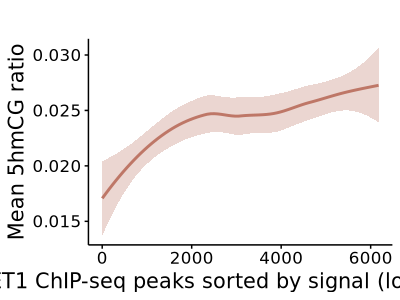

In [55]:
options(repr.plot.width = 4, repr.plot.height = 3, repr.plot.res = 100)
ggplot() +
  geom_smooth(data = aggregated_data_5hmCG, aes(x = index, y = mean_5hmCG),
              method = "loess", fill = "#BE7767", color = NA, alpha = 0.3) +
  geom_smooth(data = aggregated_data_5hmCG, aes(x = index, y = mean_5hmCG),
              method = "loess", color = "#BE7767", se = FALSE) +
  labs(title = "",
       x = "TET1 ChIP-seq peaks sorted by signal (low → high)",
       y = "Mean 5hmCG ratio") +
  theme_classic() +
  theme(
    text = element_text(size = 15),
    axis.line.x = element_line(color = "black"),
    axis.line.y = element_line(color = "black"),
    axis.text = element_text(color = "black"),
    axis.ticks = element_line(color = "black"),
    strip.text = element_text(color = "black"),
    plot.title = element_text(hjust = 0.5, color = "black"),
    panel.grid = element_blank(),
    panel.background = element_blank()
  )

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


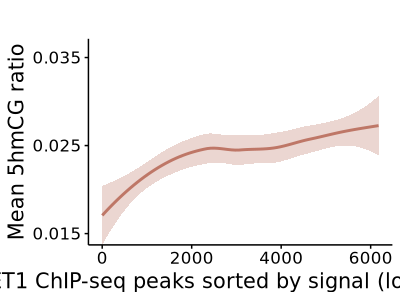

In [56]:
options(repr.plot.width = 4, repr.plot.height = 3, repr.plot.res = 100)
ggplot() +
  geom_smooth(data = aggregated_data_5hmCG, aes(x = index, y = mean_5hmCG),
              method = "loess", fill = "#BE7767", color = NA, alpha = 0.3) +
  geom_smooth(data = aggregated_data_5hmCG, aes(x = index, y = mean_5hmCG),
              method = "loess", color = "#BE7767", se = FALSE) +
  labs(title = "",
       x = "TET1 ChIP-seq peaks sorted by signal (low → high)",
       y = "Mean 5hmCG ratio") +
  theme_classic() +
  theme(
    text = element_text(size = 15),
    axis.line.x = element_line(color = "black"),
    axis.line.y = element_line(color = "black"),
    axis.text = element_text(color = "black"),
    axis.ticks = element_line(color = "black"),
    strip.text = element_text(color = "black"),
    plot.title = element_text(hjust = 0.5, color = "black"),
    panel.grid = element_blank(),
    panel.background = element_blank()
  ) +
  scale_y_continuous(
    breaks = c(0.015, 0.025, 0.035),
    expand = expansion(mult = c(0, 0.1))
  ) +
  expand_limits(y = c(0.015, 0.035))

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


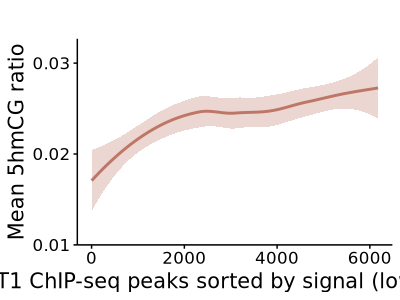

In [57]:
options(repr.plot.width = 4, repr.plot.height = 3, repr.plot.res = 100)
ggplot() +
  geom_smooth(data = aggregated_data_5hmCG, aes(x = index, y = mean_5hmCG),
              method = "loess", fill = "#BE7767", color = NA, alpha = 0.3) +
  geom_smooth(data = aggregated_data_5hmCG, aes(x = index, y = mean_5hmCG),
              method = "loess", color = "#BE7767", se = FALSE) +
  labs(title = "",
       x = "TET1 ChIP-seq peaks sorted by signal (low → high)",
       y = "Mean 5hmCG ratio") +
  theme_classic() +
  theme(
    text = element_text(size = 15),
    axis.line.x = element_line(color = "black"),
    axis.line.y = element_line(color = "black"),
    axis.text = element_text(color = "black"),
    axis.ticks = element_line(color = "black"),
    strip.text = element_text(color = "black"),
    plot.title = element_text(hjust = 0.5, color = "black"),
    panel.grid = element_blank(),
    panel.background = element_blank()
  ) +
  scale_y_continuous(
    breaks = c(0.01, 0.02, 0.03),
    expand = expansion(mult = c(0, 0.1))
  ) +
  expand_limits(y = c(0.01, 0.03))

In [58]:
aggregated_data_total5mCG <- consistent_peaks_sorted %>%
  group_by(index) %>%
  summarize(mean_total5mCG = mean(`5hmCG+5mCG`, na.rm = TRUE))

aggregated_data_total5mCG

index,mean_total5mCG
<int>,<dbl>
1,-0.0135992882
2,0.0311564588
3,0.0090754902
4,0.0121038824
5,0.0013776843
6,0.0044283848
7,0.0487795245
8,0.0108922647
9,0.0323957059


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


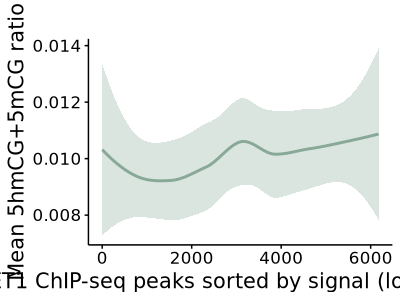

In [59]:
options(repr.plot.width = 4, repr.plot.height = 3, repr.plot.res = 100)
ggplot() +
  geom_smooth(data = aggregated_data_total5mCG, aes(x = index, y = mean_total5mCG),
              method = "loess", fill = "#88A997", color = NA, alpha = 0.3) +
  geom_smooth(data = aggregated_data_total5mCG, aes(x = index, y = mean_total5mCG),
              method = "loess", color = "#88A997", se = FALSE) +
  labs(title = "",
       x = "TET1 ChIP-seq peaks sorted by signal (low → high)",
       y = "Mean 5hmCG+5mCG ratio") +
  theme_classic() +
  theme(
    text = element_text(size = 15),
    axis.line.x = element_line(color = "black"),
    axis.line.y = element_line(color = "black"),
    axis.text = element_text(color = "black"),
    axis.ticks = element_line(color = "black"),
    strip.text = element_text(color = "black"),
    plot.title = element_text(hjust = 0.5, color = "black"),
    panel.grid = element_blank(),
    panel.background = element_blank()
  ) 

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


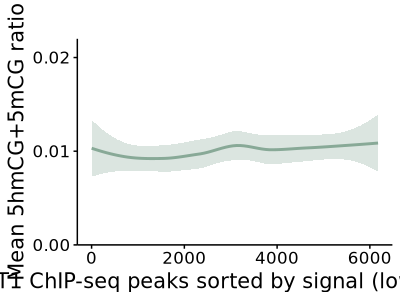

In [60]:
options(repr.plot.width = 4, repr.plot.height = 3, repr.plot.res = 100)
ggplot() +
  geom_smooth(data = aggregated_data_total5mCG, aes(x = index, y = mean_total5mCG),
              method = "loess", fill = "#88A997", color = NA, alpha = 0.3) +
  geom_smooth(data = aggregated_data_total5mCG, aes(x = index, y = mean_total5mCG),
              method = "loess", color = "#88A997", se = FALSE) +
  labs(title = "",
       x = "TET1 ChIP-seq peaks sorted by signal (low → high)",
       y = "Mean 5hmCG+5mCG ratio") +
  theme_classic() +
  theme(
    text = element_text(size = 15),
    axis.line.x = element_line(color = "black"),
    axis.line.y = element_line(color = "black"),
    axis.text = element_text(color = "black"),
    axis.ticks = element_line(color = "black"),
    strip.text = element_text(color = "black"),
    plot.title = element_text(hjust = 0.5, color = "black"),
    panel.grid = element_blank(),
    panel.background = element_blank()
  ) +
  scale_y_continuous(
    breaks = c(0, 0.01, 0.02),
    expand = expansion(mult = c(0, 0.1))
  ) +
  expand_limits(y = c(0, 0.02))

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


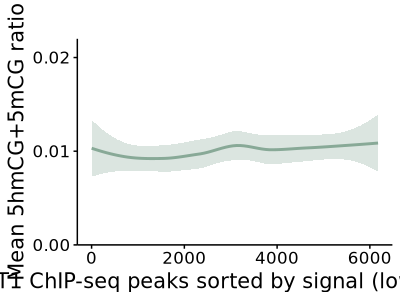

In [61]:
options(repr.plot.width = 4, repr.plot.height = 3, repr.plot.res = 100)
ggplot() +
  geom_smooth(data = aggregated_data_total5mCG, aes(x = index, y = mean_total5mCG),
              method = "loess", fill = "#88A997", color = NA, alpha = 0.3) +
  geom_smooth(data = aggregated_data_total5mCG, aes(x = index, y = mean_total5mCG),
              method = "loess", color = "#88A997", se = FALSE) +
  labs(title = "",
       x = "TET1 ChIP-seq peaks sorted by signal (low → high)",
       y = "Mean 5hmCG+5mCG ratio") +
  theme_classic() +
  theme(
    text = element_text(size = 15),
    axis.line.x = element_line(color = "black"),
    axis.line.y = element_line(color = "black"),
    axis.text = element_text(color = "black"),
    axis.ticks = element_line(color = "black"),
    strip.text = element_text(color = "black"),
    plot.title = element_text(hjust = 0.5, color = "black"),
    panel.grid = element_blank(),
    panel.background = element_blank()
  ) +
  scale_y_continuous(
    breaks = c(0, 0.01, 0.02),
    expand = expansion(mult = c(0, 0.1))
  ) +
  expand_limits(y = c(0, 0.02))

In [62]:
aggregated_data_true5mCG <- consistent_peaks_sorted %>%
  group_by(index) %>%
  summarize(mean_true5mCG = mean(`5mCG`, na.rm = TRUE))

aggregated_data_true5mCG

index,mean_true5mCG
<int>,<dbl>
1,-0.0354051647
2,0.0275058196
3,-0.0210674902
4,0.0116339412
5,0.0017703696
6,-0.0670914505
7,0.0400049902
8,-0.0775633480
9,0.0141602059


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


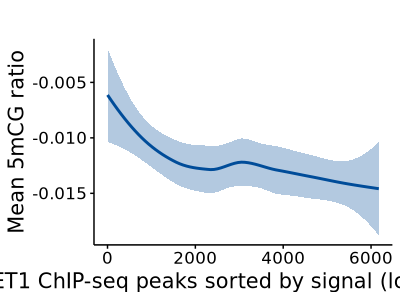

In [63]:
options(repr.plot.width = 4, repr.plot.height = 3, repr.plot.res = 100)
ggplot() +
  geom_smooth(data = aggregated_data_true5mCG, aes(x = index, y = mean_true5mCG),
              method = "loess", fill = "#004C99", color = NA, alpha = 0.3) +
  geom_smooth(data = aggregated_data_true5mCG, aes(x = index, y = mean_true5mCG),
              method = "loess", color = "#004C99", se = FALSE) +
  labs(title = "",
       x = "TET1 ChIP-seq peaks sorted by signal (low → high)",
       y = "Mean 5mCG ratio") +
  theme_classic() +
  theme(
    text = element_text(size = 15),
    axis.line.x = element_line(color = "black"),
    axis.line.y = element_line(color = "black"),
    axis.text = element_text(color = "black"),
    axis.ticks = element_line(color = "black"),
    strip.text = element_text(color = "black"),
    plot.title = element_text(hjust = 0.5, color = "black"),
    panel.grid = element_blank(),
    panel.background = element_blank()
  ) # +
#     geom_hline(yintercept = 0, color = "black")

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


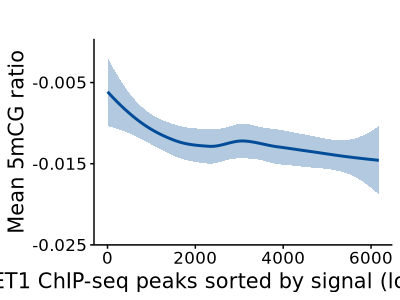

In [64]:
options(repr.plot.width = 4, repr.plot.height = 3, repr.plot.res = 100)
ggplot() +
  geom_smooth(data = aggregated_data_true5mCG, aes(x = index, y = mean_true5mCG),
              method = "loess", fill = "#004C99", color = NA, alpha = 0.3) +
  geom_smooth(data = aggregated_data_true5mCG, aes(x = index, y = mean_true5mCG),
              method = "loess", color = "#004C99", se = FALSE) +
  labs(title = "",
       x = "TET1 ChIP-seq peaks sorted by signal (low → high)",
       y = "Mean 5mCG ratio") +
  theme_classic() +
  theme(
    text = element_text(size = 15),
    axis.line.x = element_line(color = "black"),
    axis.line.y = element_line(color = "black"),
    axis.text = element_text(color = "black"),
    axis.ticks = element_line(color = "black"),
    strip.text = element_text(color = "black"),
    plot.title = element_text(hjust = 0.5, color = "black"),
    panel.grid = element_blank(),
    panel.background = element_blank()
  ) +
  scale_y_continuous(
    breaks = c(-0.025, -0.015, -0.005),
    expand = expansion(mult = c(0, 0.1))
  ) +
  expand_limits(y = c(-0.025, -0.005))

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


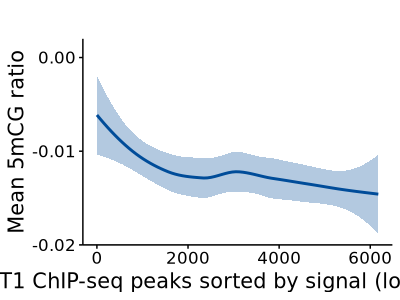

In [65]:
options(repr.plot.width = 4, repr.plot.height = 3, repr.plot.res = 100)
ggplot() +
  geom_smooth(data = aggregated_data_true5mCG, aes(x = index, y = mean_true5mCG),
              method = "loess", fill = "#004C99", color = NA, alpha = 0.3) +
  geom_smooth(data = aggregated_data_true5mCG, aes(x = index, y = mean_true5mCG),
              method = "loess", color = "#004C99", se = FALSE) +
  labs(title = "",
       x = "TET1 ChIP-seq peaks sorted by signal (low → high)",
       y = "Mean 5mCG ratio") +
  theme_classic() +
  theme(
    text = element_text(size = 15),
    axis.line.x = element_line(color = "black"),
    axis.line.y = element_line(color = "black"),
    axis.text = element_text(color = "black"),
    axis.ticks = element_line(color = "black"),
    strip.text = element_text(color = "black"),
    plot.title = element_text(hjust = 0.5, color = "black"),
    panel.grid = element_blank(),
    panel.background = element_blank()
  ) +
  scale_y_continuous(
    breaks = c(-0.02, -0.01, 0.00),
    expand = expansion(mult = c(0, 0.1))
  ) +
  expand_limits(y = c(-0.02, 0.00))

In [66]:
p1 <- ggplot() +
  geom_smooth(data = aggregated_data_5hmCG, aes(x = index, y = mean_5hmCG),
              method = "loess", fill = "#BE7767", color = NA, alpha = 0.3) +
  geom_smooth(data = aggregated_data_5hmCG, aes(x = index, y = mean_5hmCG),
              method = "loess", color = "#BE7767", se = FALSE) +
  labs(title = "",
       x = "Ranked TET1 ChIP-seq peaks",
       y = "Change of 5hmCG\n(Aged - Young)") +
  theme_classic() +
  theme(
    text = element_text(size = 15),
    axis.line.x = element_line(color = "black"),
    axis.line.y = element_line(color = "black"),
    axis.text = element_text(color = "black"),
    axis.ticks = element_line(color = "black"),
    strip.text = element_text(color = "black"),
    plot.title = element_text(hjust = 0.5, color = "black"),
    panel.grid = element_blank(),
    panel.background = element_blank()
  ) +
  scale_y_continuous(
    breaks = c(0.01, 0.02, 0.03),
    expand = expansion(mult = c(0, 0.1))
  ) +
  expand_limits(y = c(0.01, 0.03))

In [67]:
p2 <- ggplot() +
  geom_smooth(data = aggregated_data_total5mCG, aes(x = index, y = mean_total5mCG),
              method = "loess", fill = "#88A997", color = NA, alpha = 0.3) +
  geom_smooth(data = aggregated_data_total5mCG, aes(x = index, y = mean_total5mCG),
              method = "loess", color = "#88A997", se = FALSE) +
  labs(title = "",
       x = "Ranked TET1 ChIP-seq peaks",
       y = "Change of 5hmCG+5mCG\n(Aged - Young)") +
  theme_classic() +
  theme(
    text = element_text(size = 15),
    axis.line.x = element_line(color = "black"),
    axis.line.y = element_line(color = "black"),
    axis.text = element_text(color = "black"),
    axis.ticks = element_line(color = "black"),
    strip.text = element_text(color = "black"),
    plot.title = element_text(hjust = 0.5, color = "black"),
    panel.grid = element_blank(),
    panel.background = element_blank()
  ) +
  scale_y_continuous(
    breaks = c(0.00, 0.01, 0.02),
    expand = expansion(mult = c(0, 0.1))
  ) +
  expand_limits(y = c(0.00, 0.02))

In [68]:
p3 <- ggplot() +
  geom_smooth(data = aggregated_data_true5mCG, aes(x = index, y = mean_true5mCG),
              method = "loess", fill = "#004C99", color = NA, alpha = 0.3) +
  geom_smooth(data = aggregated_data_true5mCG, aes(x = index, y = mean_true5mCG),
              method = "loess", color = "#004C99", se = FALSE) +
  labs(title = "",
       x = "Ranked TET1 ChIP-seq peaks",
       y = "Change of 5mCG\n(Aged - Young)") +
  theme_classic() +
  theme(
    text = element_text(size = 15),
    axis.line.x = element_line(color = "black"),
    axis.line.y = element_line(color = "black"),
    axis.text = element_text(color = "black"),
    axis.ticks = element_line(color = "black"),
    strip.text = element_text(color = "black"),
    plot.title = element_text(hjust = 0.5, color = "black"),
    panel.grid = element_blank(),
    panel.background = element_blank()
  ) +
  scale_y_continuous(
    breaks = c(-0.02, -0.01, 0.00),
    expand = expansion(mult = c(0, 0.1))
  ) +
  expand_limits(y = c(-0.02, 0.00))

In [69]:
library(gridExtra)
library(ggplot2)


Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine




In [70]:
gpp1 <- arrangeGrob(p1, heights = unit(3, "inches"), widths = unit(4, "inches"))
gpp2 <- arrangeGrob(p2, heights = unit(3, "inches"), widths = unit(4, "inches"))
gpp3 <- arrangeGrob(p3, heights = unit(3, "inches"), widths = unit(4, "inches"))

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


In [71]:
combined_plot <- arrangeGrob(gpp1, gpp2, gpp3, ncol = 1, nrow = 3)

In [ ]:
ggsave("../../output/03.Aging_Mouse/05-ChIP-seq/09-combined_subclass_lineplot_CG_split_20250303.pdf", 
       combined_plot, 
       width = 6.4, height = 9)